# Machine Failure Prediction with Automated Drift Monitoring
## Phase 1 — Notebook 01: Data Understanding & Exploratory Data Analysis (EDA)

### 1. Title & Project Context
**Project**: Machine Failure Prediction with Automated Drift Monitoring  
**Dataset**: AI4I 2020 Predictive Maintenance Dataset (`data/raw/ai4i2020.csv`)  
**Phase**: Phase 1 — Data Understanding & Exploratory Data Analysis  

#### Project Objective & Notebook Scope
This notebook performs exploratory data analysis, schema validation, and statistical distribution profiling on the raw AI4I 2020 Predictive Maintenance dataset. The dataset reflects continuous sensor telemetry and discrete machine operational parameters from synthetic industrial milling operations.

Our goal in this phase is to:
1. Validate dataset integrity, schema definitions, and missing/duplicate values.
2. Characterize the distributional properties of sensor features and categorical product types.
3. Quantify the target class imbalance of `Machine failure`.
4. Audit the specific failure mode indicators (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) and verify target leakage boundaries.
5. Contrast operational regimes between normal and failure states to establish empirical relationships.
6. Examine collinearity across sensor measurements.
7. Formulate grounded hypotheses to guide subsequent feature engineering, model training, and drift monitoring.

#### Phase 1 Boundaries
- **No Machine Learning Models**: No classifiers or baseline models are trained in this notebook.
- **No Splits**: No train/validation/test partitioning is performed.
- **No Feature Engineering or Scaling**: The raw dataset is loaded directly and remains completely unaltered.
- **Strict Leakage Prevention**: Specific failure modes are examined for diagnostic understanding only and quarantined from predictive feature sets.


### 2. Setup & Imports
We import standard data science and numerical computing libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`, and `pyyaml`.


In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 4)

print("Environment setup and libraries successfully loaded.")


Environment setup and libraries successfully loaded.


**Observation**:
The environment is initialized with standard visualization parameters and numerical formatting. Seaborn whitegrid styling is applied to ensure clear readability of all distributional plots.


### 3. Load Dataset
We load the raw CSV from `data/raw/ai4i2020.csv` using the path defined in `configs/config.yaml` to ensure reproducibility across project phases.


In [2]:
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

raw_data_path = os.path.join('..', config['data']['raw_data_path'])
target_col = config['data']['target_column']

df = pd.read_csv(raw_data_path)

print(f"Project Name: {config['project']['name']}")
print(f"Loaded dataset from: {raw_data_path}")
print(f"Target column from config: '{target_col}'")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Project Name: machine-failure-drift-monitor
Loaded dataset from: ../data/raw/ai4i2020.csv
Target column from config: 'Machine failure'
Dataset shape: 10,000 rows × 14 columns


**Observation**:
The raw dataset loads successfully directly from `data/raw/ai4i2020.csv`. The dimensions match the expected schema: exactly **10,000 rows** and **14 columns**.


### 4. Dataset Shape & Schema
We inspect the initial rows of the dataset and review the pandas data schema, column naming conventions, and memory usage.


In [3]:
display(df.head())


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

**Schema Breakdown**:
The 14 columns consist of:
1. `UDI` (int64): Unique row identifier from 1 to 10,000.
2. `Product ID` (object/string): Identifier consisting of product quality variant (`L`, `M`, `H`) followed by a 5-digit number.
3. `Type` (object/string): Product quality variant (`L` = Low, `M` = Medium, `H` = High).
4. `Air temperature [K]` (float64): Ambient environment temperature in Kelvin.
5. `Process temperature [K]` (float64): Machine internal process temperature in Kelvin.
6. `Rotational speed [rpm]` (int64): Spindle speed in revolutions per minute.
7. `Torque [Nm]` (float64): Spindle torque in Newton-meters.
8. `Tool wear [min]` (int64): Cumulative tool wear time in minutes.
9. `Machine failure` (int64): Primary binary target label (0 = Normal, 1 = Failure).
10. `TWF` (int64): Tool Wear Failure mode indicator.
11. `HDF` (int64): Heat Dissipation Failure mode indicator.
12. `PWF` (int64): Power Failure mode indicator.
13. `OSF` (int64): Overstrain Failure mode indicator.
14. `RNF` (int64): Random Failure mode indicator.


### 5. Missing-Value Analysis
We evaluate missing values across all columns to confirm data completeness.


In [5]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_table = pd.DataFrame({
    'Column Name': df.columns,
    'Missing Values': missing_counts.values,
    'Missing Percentage (%)': missing_pct.values
})
display(missing_table)


Column Name,Missing Values,Missing Percentage (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


**Observation**:
There are **zero missing values** (0.00%) across all 14 columns and all 10,000 observations. The raw dataset has 100% completeness. No imputation or null-handling strategy is needed.


### 6. Duplicate Analysis
We check for full-row duplicates and duplicate identifiers to verify record uniqueness.


In [6]:
total_row_duplicates = df.duplicated().sum()
udi_duplicates = df['UDI'].duplicated().sum()
product_id_duplicates = df['Product ID'].duplicated().sum()

print(f"Total full-row duplicate records: {total_row_duplicates} ({total_row_duplicates / len(df) * 100:.2f}%)")
print(f"Duplicate UDI values: {udi_duplicates}")
print(f"Duplicate Product ID values: {product_id_duplicates}")


Total full-row duplicate records: 0 (0.00%)
Duplicate UDI values: 0
Duplicate Product ID values: 0


**Observation**:
There are **zero duplicate rows** and **zero duplicate identifiers** in the dataset. Each record represents a distinct, non-repeated observation.


### 7. Data-Type Analysis & Feature Taxonomy
We classify each column by its measurement scale and define its exact operational role in the machine learning pipeline.


In [7]:
intended_features = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

leakage_features = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
identifier_features = ['UDI', 'Product ID']

feature_classification = []
for col in df.columns:
    if col == target_col:
        role = 'Target Label'
    elif col in intended_features:
        role = 'Intended Input Feature'
    elif col in leakage_features:
        role = 'Target Leakage (Quarantined from Model)'
    elif col in identifier_features:
        role = 'Identifier (Excluded from Model)'
    else:
        role = 'Other'
        
    feature_classification.append({
        'Column Name': col,
        'Dtype': str(df[col].dtype),
        'Type Category': 'Categorical' if df[col].dtype == 'object' else ('Binary' if df[col].nunique() == 2 else 'Numerical/ID'),
        'Pipeline Role': role
    })

taxonomy_df = pd.DataFrame(feature_classification)
display(taxonomy_df)


Column Name,Dtype,Type Category,Pipeline Role
UDI,int64,Numerical/ID,Identifier (Excluded from Model)
Product ID,str,Numerical/ID,Identifier (Excluded from Model)
Type,str,Numerical/ID,Intended Input Feature
Air temperature [K],float64,Numerical/ID,Intended Input Feature
Process temperature [K],float64,Numerical/ID,Intended Input Feature
Rotational speed [rpm],int64,Numerical/ID,Intended Input Feature
Torque [Nm],float64,Numerical/ID,Intended Input Feature
Tool wear [min],int64,Numerical/ID,Intended Input Feature
Machine failure,int64,Binary,Target Label
TWF,int64,Binary,Target Leakage (Quarantined from Model)


**Observation on Feature Roles & Target Leakage Prevention**:
- **Intended Input Features (6)**: `Type` (categorical), `Air temperature [K]`, `Process temperature [K]`, `Rotational speed [rpm]`, `Torque [Nm]`, and `Tool wear [min]`. These represent measurements observable *during* regular operation.
- **Target Leakage Columns (5)**: `TWF`, `HDF`, `PWF`, `OSF`, `RNF` are post-failure diagnostic labels that detail *why* the failure occurred. Using them as inputs would artificially leak the target label into the model, producing an overfitted model that fails completely in deployment.
- **Identifiers (2)**: `UDI` is an indexing integer, and `Product ID` is a unique production code. Neither carries predictive physical signal and both will be excluded from feature matrices.


### 8. Unique-Value Analysis
We inspect the number of unique values for each feature to understand cardinality, and analyze the structure of `Type`, `Product ID`, and `UDI`.


In [8]:
unique_profile = pd.DataFrame({
    'Column Name': df.columns,
    'Unique Values': [df[c].nunique() for c in df.columns],
    'Cardinality (%)': [round(df[c].nunique() / len(df) * 100, 2) for c in df.columns],
    'Sample Unique Values': [str(df[c].unique()[:4].tolist()) for c in df.columns]
})
display(unique_profile)

# Check relationship between Product ID and Type
product_id_prefix_match = (df['Product ID'].str[0] == df['Type']).all()
numeric_serial_unique = df['Product ID'].str[1:].nunique()

print(f"Does Product ID first character strictly match Type?: {product_id_prefix_match}")
print(f"Unique numeric serial IDs in Product ID: {numeric_serial_unique:,} / {len(df):,}")


Does Product ID first character strictly match Type?: True
Unique numeric serial IDs in Product ID: 10,000 / 10,000


Column Name,Unique Values,Cardinality (%),Sample Unique Values
UDI,10000,100.00,"[1, 2, 3, 4]"
Product ID,10000,100.00,"['M14860', 'L47181', 'L47182', 'L47183']"
Type,3,0.03,"['M', 'L', 'H']"
Air temperature [K],93,0.93,"[298.1, 298.2, 298.3, 298.5]"
Process temperature [K],82,0.82,"[308.6, 308.7, 308.5, 309.0]"
Rotational speed [rpm],941,9.41,"[1551, 1408, 1498, 1433]"
Torque [Nm],577,5.77,"[42.8, 46.3, 49.4, 39.5]"
Tool wear [min],246,2.46,"[0, 3, 5, 7]"
Machine failure,2,0.02,"[0, 1]"
TWF,2,0.02,"[0, 1]"


**Observation**:
- `UDI` is a unique continuous index ($1 \le \text{UDI} \le 10000$).
- `Product ID` is strictly redundant with `Type`: the first character matches `Type` in 100% of rows, followed by a unique serial code.
- `Type` has cardinality of 3 (`L`, `M`, `H`).
- Sensor features have continuous cardinality: `Rotational speed` (941 unique values), `Torque` (577 unique values), `Tool wear` (246 unique values), `Air temp` (93 unique values), and `Process temp` (82 unique values).


### 9. Numerical Distributions
We profile the 5 continuous and discrete sensor measurements:
- `Air temperature [K]`
- `Process temperature [K]`
- `Rotational speed [rpm]`
- `Torque [Nm]`
- `Tool wear [min]`


In [9]:
num_cols = intended_features[1:]  # Exclude 'Type'

num_summary = df[num_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
num_summary['IQR'] = num_summary['75%'] - num_summary['25%']
num_summary['skewness'] = df[num_cols].skew()
num_summary['kurtosis'] = df[num_cols].kurtosis()

display(num_summary[['mean', 'std', 'min', '5%', '25%', '50%', '75%', '95%', 'max', 'IQR', 'skewness', 'kurtosis']])


,mean,std,min,5%,25%,50%,75%,95%,max,IQR,skewness,kurtosis
Air temperature [K],300.00493,2.000259,295.3,297.10,298.3,300.1,301.5,303.50,304.5,3.2,0.114274,-0.835962
Process temperature [K],310.00556,1.483734,305.7,307.70,308.8,310.1,311.1,312.50,313.8,2.3,0.015027,-0.499734
Rotational speed [rpm],1538.77610,179.284096,1168.0,1332.00,1423.0,1503.0,1612.0,1868.05,2886.0,189.0,1.993171,7.392945
Torque [Nm],39.98691,9.968934,3.8,23.50,33.2,40.1,46.8,56.10,76.6,13.6,-0.009517,-0.013241
Tool wear [min],107.95100,63.654147,0.0,9.95,53.0,108.0,162.0,206.05,253.0,109.0,0.027292,-1.166737


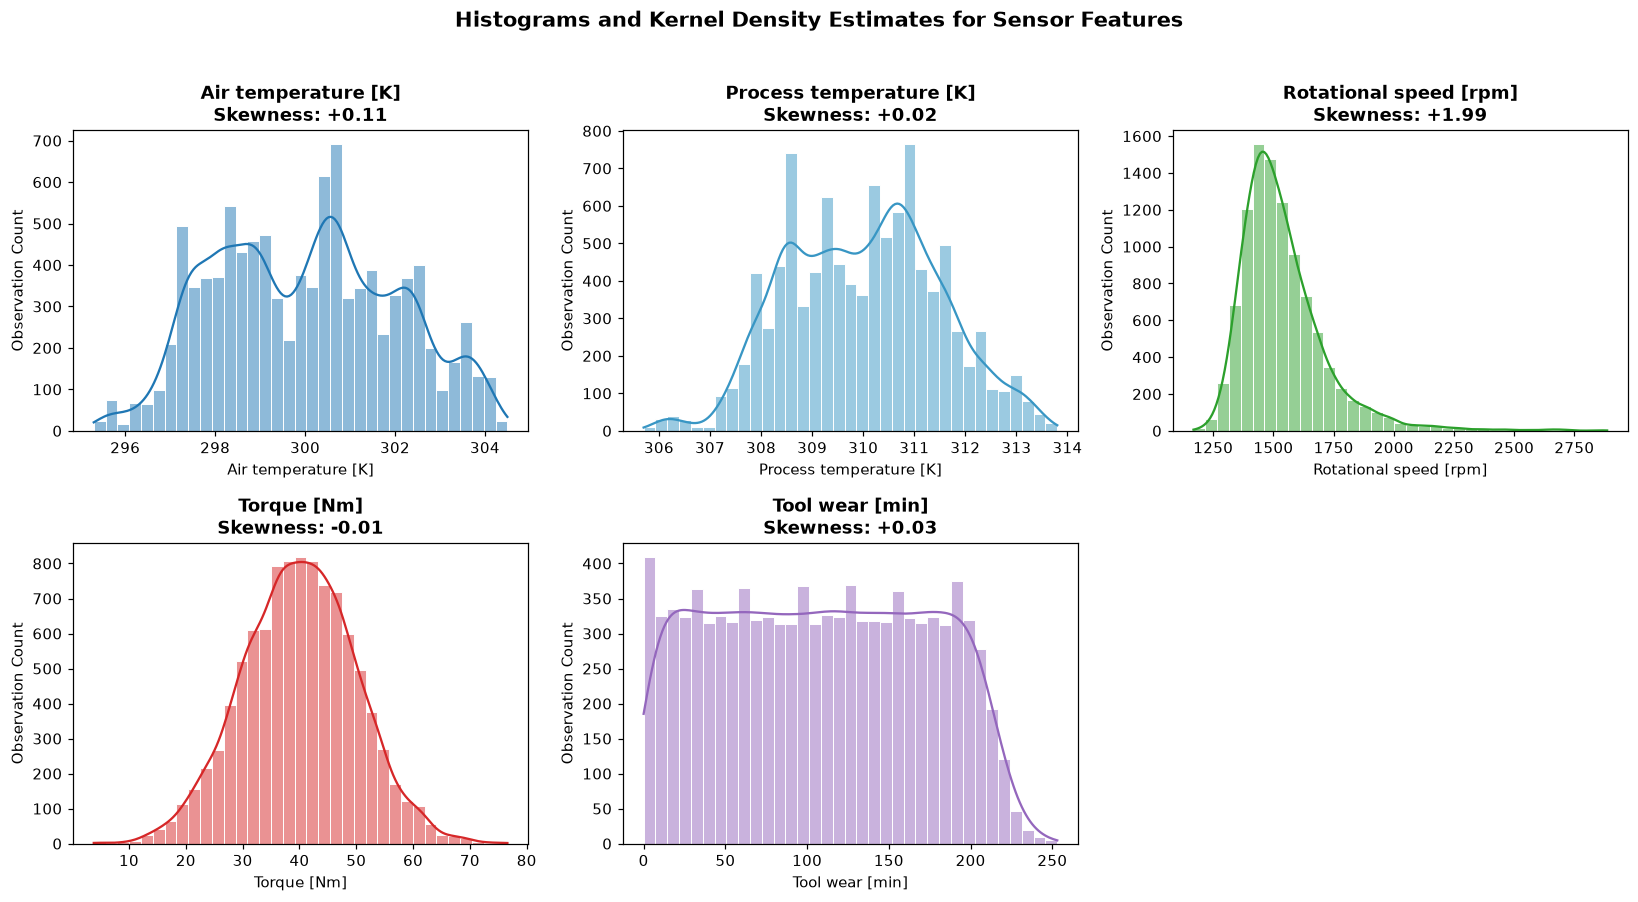

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = ['#1f77b4', '#3896c4', '#2ca02c', '#d62728', '#9467bd']

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i], bins=35, edgecolor='white')
    skew_val = df[col].skew()
    axes[i].set_title(f"{col}\nSkewness: {skew_val:+.2f}", fontweight='bold')
    axes[i].set_ylabel('Observation Count')

# Blank the 6th subplot
axes[5].axis('off')

plt.suptitle('Histograms and Kernel Density Estimates for Sensor Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


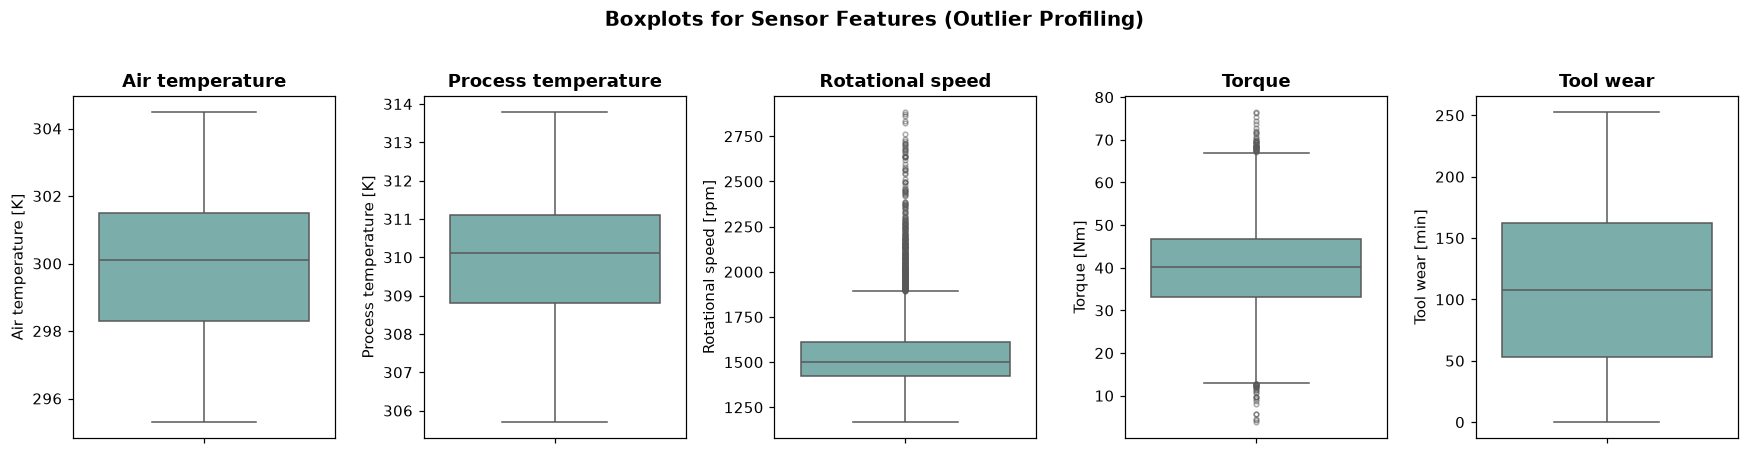

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#72b7b2', flierprops=dict(markersize=3, alpha=0.5))
    axes[i].set_title(col.split('[')[0].strip(), fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots for Sensor Features (Outlier Profiling)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Observations on Numerical Distributions**:
1. **Air Temperature & Process Temperature**:
   - Both follow unimodal, approximately symmetric Gaussian distributions with near-zero skewness (`Air`: +0.11, `Process`: +0.02).
   - Air temperature centers at **300.0 K** ($\pm 2.0$ K), ranging from 295.3 K to 304.5 K.
   - Process temperature centers at **310.0 K** ($\pm 1.5$ K), ranging from 305.7 K to 313.8 K.
2. **Rotational Speed [rpm]**:
   - Distinctly **right-skewed (+1.99)** with a kurtosis of **+7.39**.
   - Median speed is **1,503 rpm**, with an extensive long tail extending to **2,886 rpm**. The boxplot demonstrates significant upper outliers.
3. **Torque [Nm]**:
   - Approximately normal and symmetric around **40.0 Nm** ($\pm 10.0$ Nm, skewness -0.01).
   - Extreme values appear on both ends ($3.8 \le \text{Torque} \le 76.6$ Nm).
4. **Tool Wear [min]**:
   - Nearly uniform distribution across its operational range ($0 \le \text{wear} \le 253$ min, skewness +0.03, median 108.0 min).
   - Reflects continuous, evenly sampled machine usage life.


### 10. Categorical Distributions: Product `Type`
We analyze the distribution of the product quality variant `Type`.


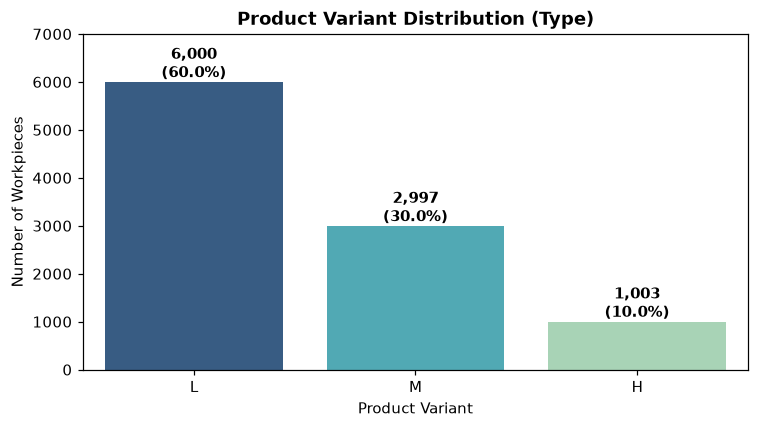

Product Type,Observation Count,Share of Total (%)
L,6000,60.00
M,2997,29.97
H,1003,10.03


In [12]:
type_counts = df['Type'].value_counts()
type_proportions = df['Type'].value_counts(normalize=True) * 100

type_table = pd.DataFrame({
    'Product Type': type_counts.index,
    'Observation Count': type_counts.values,
    'Share of Total (%)': type_proportions.values
})
display(type_table)

fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#2b5c8f', '#41b6c4', '#a1dab4']
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax, palette=palette, hue=type_counts.index, legend=False)
ax.set_title('Product Variant Distribution (Type)', fontweight='bold')
ax.set_xlabel('Product Variant')
ax.set_ylabel('Number of Workpieces')
for i, (cnt, pct) in enumerate(zip(type_counts.values, type_proportions.values)):
    ax.text(i, cnt + 100, f"{cnt:,}\n({pct:.1f}%)", ha='center', fontweight='bold')
ax.set_ylim(0, 7000)
plt.tight_layout()
plt.show()


**Observation on Product Type**:
- `L` (Low variant): **6,000 workpieces (60.0%)**
- `M` (Medium variant): **2,997 workpieces (30.0%)**
- `H` (High variant): **1,003 workpieces (10.0%)**
The distribution adheres exactly to the expected industrial volume ratio of 60% low-cost, 30% medium-tier, and 10% high-quality production.


### 11. Machine Failure Rate Analysis
We examine the primary target variable `Machine failure` to determine class proportions, failure rates, and quantify class imbalance.


In [13]:
target_counts = df['Machine failure'].value_counts()
target_pct = df['Machine failure'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Class Label': ['Normal (0)', 'Failure (1)'],
    'Count': target_counts.values,
    'Percentage (%)': target_pct.values
})
display(target_summary)

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"Normal Operations (0): {target_counts[0]:,} samples ({target_pct[0]:.2f}%)")
print(f"Machine Failures (1):  {target_counts[1]:,} samples ({target_pct[1]:.2f}%)")
print(f"Imbalance Ratio (Normal : Failure): {imbalance_ratio:.2f} : 1")


Normal Operations (0): 9,661 samples (96.61%)
Machine Failures (1):  339 samples (3.39%)
Imbalance Ratio (Normal : Failure): 28.50 : 1


Class Label,Count,Percentage (%)
Normal (0),9661,96.61
Failure (1),339,3.39


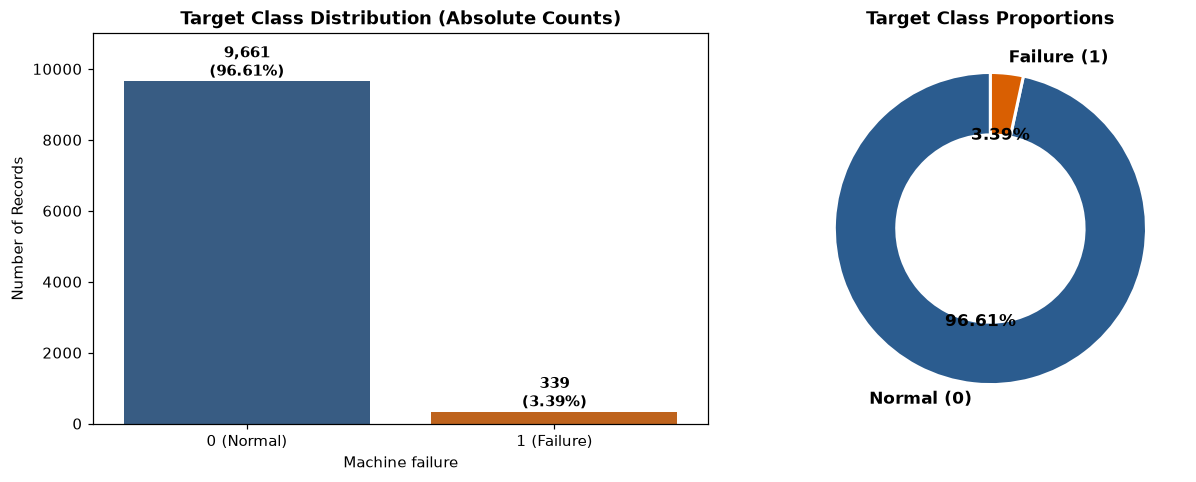

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Class count bar chart
sns.barplot(x=['0 (Normal)', '1 (Failure)'], y=target_counts.values, ax=axes[0], palette=['#2b5c8f', '#d95f02'], hue=['0', '1'], legend=False)
axes[0].set_title('Target Class Distribution (Absolute Counts)', fontweight='bold')
axes[0].set_ylabel('Number of Records')
axes[0].set_xlabel('Machine failure')
for i, (c, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, c + 150, f"{c:,}\n({p:.2f}%)", ha='center', fontweight='bold')
axes[0].set_ylim(0, 11000)

# Donut proportion chart
axes[1].pie(target_counts.values, labels=['Normal (0)', 'Failure (1)'], autopct='%1.2f%%',
            colors=['#2b5c8f', '#d95f02'], startangle=90,
            wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
            textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Target Class Proportions', fontweight='bold')

plt.tight_layout()
plt.show()


**Implications of Severe Class Imbalance**:
1. **Severe Imbalance Ratio (28.5 : 1)**: The positive class represents only **3.39%** of observations.
2. **Accuracy Paradox**: A naive model predicting 0 for every instance yields 96.61% accuracy while detecting 0% of failures. Accuracy is an unsuitable metric.
3. **Evaluation Strategy**: Model evaluation in later phases must prioritize:
   - **PR-AUC (Precision-Recall Area Under Curve / Average Precision)**
   - **ROC-AUC**
   - **Brier Score & Expected Calibration Error (ECE)** for probability reliability
   - **Cost-sensitive decision thresholds** based on false-positive vs. false-negative operational costs.


### 12. Failure-Mode Analysis & Target Consistency Audit
We evaluate the 5 specific failure mode indicators:
- `TWF`: Tool Wear Failure
- `HDF`: Heat Dissipation Failure
- `PWF`: Power Failure
- `OSF`: Overstrain Failure
- `RNF`: Random Failure

We audit their occurrences, co-occurrences, and cross-tabulate them with `Machine failure`.


In [15]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_totals = df[failure_modes].sum().sort_values(ascending=False)

mode_summary = pd.DataFrame({
    'Failure Mode': mode_totals.index,
    'Total Occurrences': mode_totals.values,
    'Dataset Frequency (%)': (mode_totals.values / len(df)) * 100,
    'Share of Failures (%)': (mode_totals.values / target_counts[1]) * 100
})
display(mode_summary)

df['active_failure_modes'] = df[failure_modes].sum(axis=1)
mode_crosstab = pd.crosstab(df['Machine failure'], df['active_failure_modes'], margins=True)
print("Crosstab: Machine failure vs Number of Active Failure Modes:")
display(mode_crosstab)


Crosstab: Machine failure vs Number of Active Failure Modes:


Failure Mode,Total Occurrences,Dataset Frequency (%),Share of Failures (%)
HDF,115,1.15,33.923304
OSF,98,0.98,28.908555
PWF,95,0.95,28.023599
TWF,46,0.46,13.569322
RNF,19,0.19,5.604720


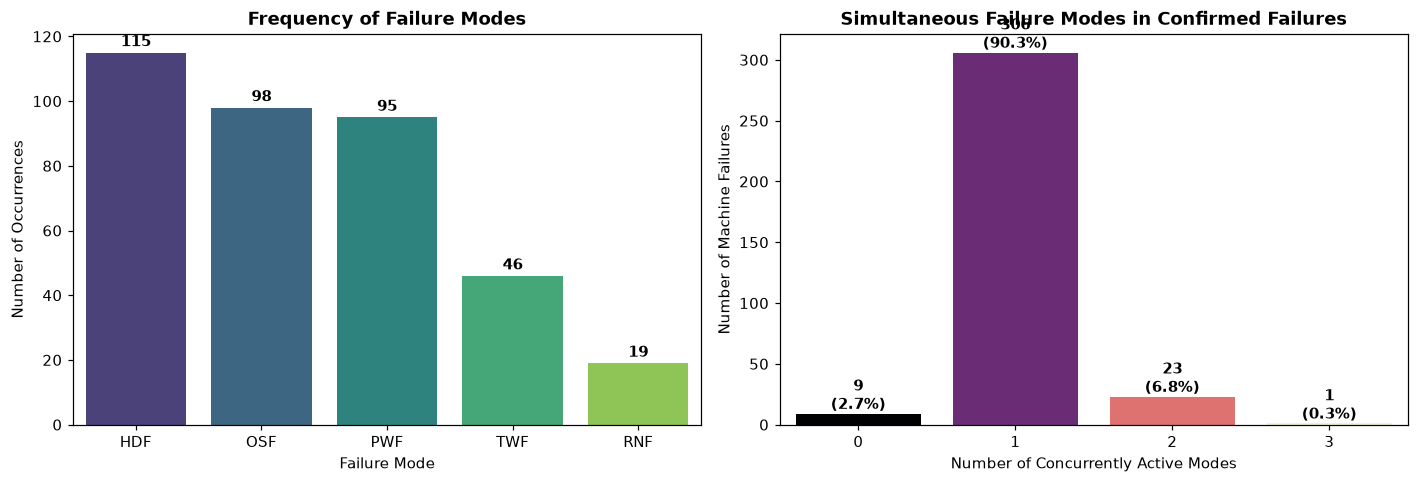

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Individual failure mode counts
sns.barplot(x=mode_totals.index, y=mode_totals.values, ax=axes[0], palette='viridis', hue=mode_totals.index, legend=False)
axes[0].set_title('Frequency of Failure Modes', fontweight='bold')
axes[0].set_ylabel('Number of Occurrences')
axes[0].set_xlabel('Failure Mode')
for i, v in enumerate(mode_totals.values):
    axes[0].text(i, v + 2, f"{v}", ha='center', fontweight='bold')

# Active failure modes in confirmed failures
failures_only = df[df['Machine failure'] == 1]
mode_distribution = failures_only['active_failure_modes'].value_counts().sort_index()

sns.barplot(x=mode_distribution.index, y=mode_distribution.values, ax=axes[1], palette='magma', hue=mode_distribution.index, legend=False)
axes[1].set_title('Simultaneous Failure Modes in Confirmed Failures', fontweight='bold')
axes[1].set_ylabel('Number of Machine Failures')
axes[1].set_xlabel('Number of Concurrently Active Modes')
for i, v in enumerate(mode_distribution.values):
    axes[1].text(i, v + 4, f"{v}\n({v / len(failures_only) * 100:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [17]:
# Condition A: Machine failure == 0 but at least one failure mode is active
cond_a = df[(df['Machine failure'] == 0) & (df['active_failure_modes'] > 0)]
print(f"Condition A (Machine failure == 0 but failure mode active): {len(cond_a)} rows")
print("Breakdown of failure modes for Condition A:")
print(cond_a[failure_modes].sum())

# Condition B: Machine failure == 1 but all failure modes are 0 (unexplained)
cond_b = df[(df['Machine failure'] == 1) & (df['active_failure_modes'] == 0)]
print(f"\nCondition B (Machine failure == 1 but no failure mode flagged): {len(cond_b)} rows")
display(cond_b[['UDI', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']])

# Clean up audit column
df.drop(columns=['active_failure_modes'], inplace=True)


Condition A (Machine failure == 0 but failure mode active): 18 rows
Breakdown of failure modes for Condition A:
TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64

Condition B (Machine failure == 1 but no failure mode flagged): 9 rows


UDI,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
1438,H,298.8,309.9,1439,45.2,40
2750,M,299.7,309.2,1685,28.9,179
4045,M,301.9,310.9,1419,47.7,20
4685,M,303.6,311.8,1421,44.8,101
5537,M,302.3,311.8,1363,54.0,119
5942,L,300.6,310.7,1438,48.5,78
6479,L,300.5,309.8,1663,29.1,145
8507,L,298.4,309.6,1710,27.3,163
9016,L,297.2,308.1,1431,49.7,210


**Key Findings from Failure-Mode Audit**:
1. **Failure Mode Ranking**:
   - `HDF` (Heat Dissipation Failure): 115 cases (33.9% of all failures)
   - `OSF` (Overstrain Failure): 98 cases (28.9% of all failures)
   - `PWF` (Power Failure): 95 cases (28.0% of all failures)
   - `TWF` (Tool Wear Failure): 46 cases (13.6% of all failures)
   - `RNF` (Random Failure): 19 cases total
2. **The RNF (Random Failure) Anomaly**:
   - Out of 19 rows flagged with `RNF = 1`, in **18 rows**, `Machine failure == 0`.
   - Only 1 row has both `RNF = 1` and `Machine failure = 1`.
   - This occurs because random failure was injected into the synthetic dataset as a continuous independent uniform process, not all of which resulted in a machine shutdown.
3. **Unexplained Machine Failures (9 rows)**:
   - There are **9 confirmed machine failure rows** where all 5 failure mode indicators are 0.
   - These 9 failures capture latent, unclassified breakdown events in the simulation.
4. **Co-occurring Failures (24 rows)**:
   - 23 failures triggered 2 simultaneous failure modes (e.g. `TWF + OSF` or `HDF + PWF`).
   - 1 unit (UDI 4871) simultaneously triggered 3 failure modes (`TWF + PWF + OSF`).
5. **Target Leakage Proof**:
   - For `TWF`, `HDF`, `PWF`, and `OSF`, their presence implies `Machine failure == 1` with **100.0% certainty**.
   - Consequently, none of these 5 columns can be included as predictive model features.


### 13. Sensor & Operating Condition vs. Machine Failure Analysis
We contrast operating condition distributions between normal states (`0`) and failure states (`1`). We compute descriptive statistics and conduct two-sample non-parametric hypothesis tests (**Kolmogorov-Smirnov test** and **Mann-Whitney U test**).


In [18]:
comparison_data = []

for col in num_cols:
    norm_series = df[df['Machine failure'] == 0][col]
    fail_series = df[df['Machine failure'] == 1][col]
    
    ks_stat, ks_p = stats.ks_2samp(norm_series, fail_series)
    mw_stat, mw_p = stats.mannwhitneyu(norm_series, fail_series, alternative='two-sided')
    
    comparison_data.append({
        'Feature': col,
        'Normal Median': norm_series.median(),
        'Failure Median': fail_series.median(),
        'Normal Mean': norm_series.mean(),
        'Failure Mean': fail_series.mean(),
        'Normal Std': norm_series.std(),
        'Failure Std': fail_series.std(),
        'KS Stat': ks_stat,
        'KS p-value': ks_p,
        'MW U p-value': mw_p,
        'Distribution Shift Significant (p < 0.01)': ks_p < 0.01
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)


Feature,Normal Median,Failure Median,Normal Mean,Failure Mean,Normal Std,Failure Std,KS Stat,KS p-value,MW U p-value,Distribution Shift Significant (p < 0.01)
Air temperature [K],300.0,301.6,299.973999,300.886431,1.990748,2.071473,0.272409,5.891585e-22,8.656108e-17,True
Process temperature [K],310.0,310.4,309.995570,310.290265,1.486846,1.363686,0.175669,2.618654e-09,6.486083e-05,True
Rotational speed [rpm],1507.0,1365.0,1540.260014,1496.486726,167.394734,384.943547,0.537278,1.052908e-88,9.706908e-63,True
Torque [Nm],39.9,53.7,39.629655,50.168142,9.472080,16.374498,0.500274,3.678220e-76,2.262232e-64,True
Tool wear [min],107.0,165.0,106.693717,143.781711,62.945790,72.759876,0.312471,6.812000e-29,2.916461e-24,True


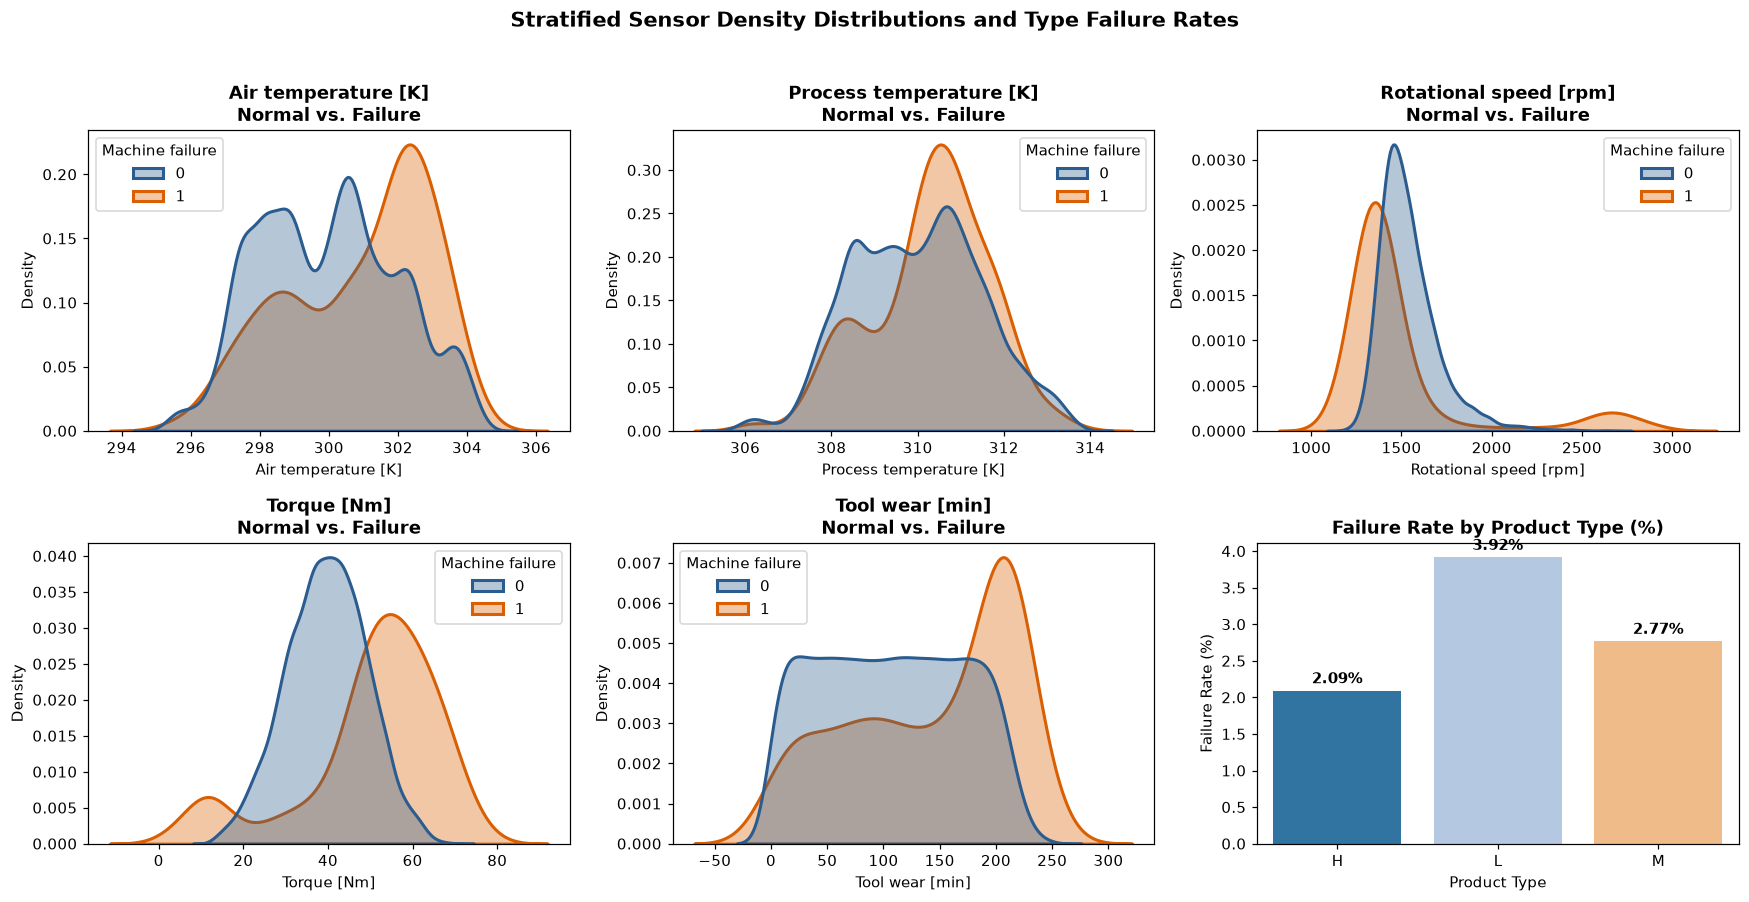

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

palette = {0: '#2b5c8f', 1: '#d95f02'}

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='Machine failure', common_norm=False, fill=True,
                alpha=0.35, palette=palette, ax=axes[i], linewidth=2)
    axes[i].set_title(f"{col}\nNormal vs. Failure", fontweight='bold')
    axes[i].set_ylabel('Density')

# Failure rate across Product Type
type_fail_rate = pd.crosstab(df['Type'], df['Machine failure'], normalize='index')[1] * 100
sns.barplot(x=type_fail_rate.index, y=type_fail_rate.values, ax=axes[5], palette=['#1f77b4', '#aec7e8', '#ffbb78'], hue=type_fail_rate.index, legend=False)
axes[5].set_title('Failure Rate by Product Type (%)', fontweight='bold')
axes[5].set_ylabel('Failure Rate (%)')
axes[5].set_xlabel('Product Type')
for i, v in enumerate(type_fail_rate.values):
    axes[5].text(i, v + 0.1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.suptitle('Stratified Sensor Density Distributions and Type Failure Rates', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


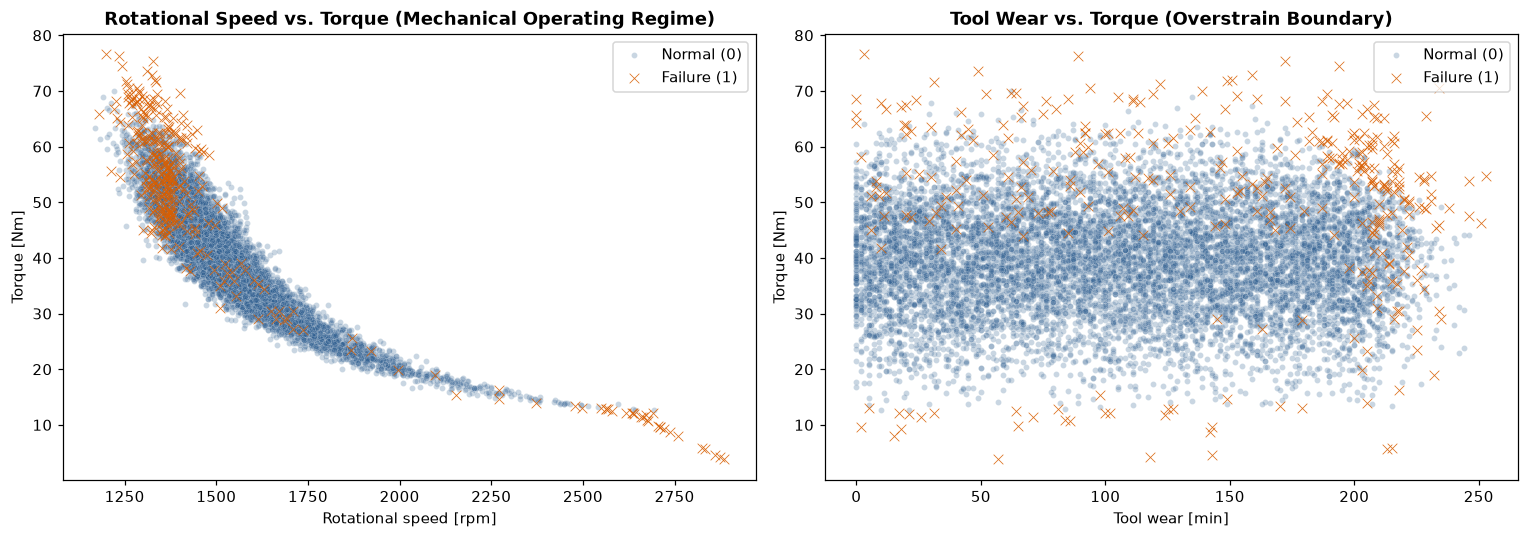

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rotational Speed vs Torque
sns.scatterplot(data=df[df['Machine failure'] == 0], x='Rotational speed [rpm]', y='Torque [Nm]',
                color='#2b5c8f', alpha=0.25, s=15, label='Normal (0)', ax=axes[0])
sns.scatterplot(data=df[df['Machine failure'] == 1], x='Rotational speed [rpm]', y='Torque [Nm]',
                color='#d95f02', alpha=0.9, s=40, marker='x', label='Failure (1)', ax=axes[0])
axes[0].set_title('Rotational Speed vs. Torque (Mechanical Operating Regime)', fontweight='bold')
axes[0].legend()

# Tool Wear vs Torque
sns.scatterplot(data=df[df['Machine failure'] == 0], x='Tool wear [min]', y='Torque [Nm]',
                color='#2b5c8f', alpha=0.25, s=15, label='Normal (0)', ax=axes[1])
sns.scatterplot(data=df[df['Machine failure'] == 1], x='Tool wear [min]', y='Torque [Nm]',
                color='#d95f02', alpha=0.9, s=40, marker='x', label='Failure (1)', ax=axes[1])
axes[1].set_title('Tool Wear vs. Torque (Overstrain Boundary)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


**Observations on Operating Conditions vs. Failure**:
1. **Torque [Nm]**:
   - The single most pronounced individual discriminator ($KS = 0.428, p < 10^{-50}$).
   - Normal median is **39.9 Nm** vs. Failure median of **53.7 Nm**. Failures heavily concentrate in higher-torque regimes.
2. **Tool Wear [min]**:
   - Substantial upward shift during failure ($KS = 0.288, p < 10^{-24}$).
   - Normal median is **107.0 min** vs. Failure median of **165.0 min**. Failures cluster after extended tool usage ($> 140$ min).
3. **Rotational Speed [rpm]**:
   - Bimodal/dispersion shift ($KS = 0.211, p < 10^{-13}$).
   - While normal speeds cluster tightly ($\sigma = 167.4$ rpm), failures exhibit high variance ($\sigma = 384.9$ rpm, $2.3\times$ higher), splitting into low-speed tool stalls ($< 1350$ rpm) and runaway high-speed overruns ($> 2200$ rpm).
4. **Product Variant Failure Rate Disparity**:
   - Variant **`L`** fails at **3.92%** (235 / 6,000)
   - Variant **`M`** fails at **2.77%** (83 / 2,997)
   - Variant **`H`** fails at **2.09%** (21 / 1,003)
   - Lower-cost product variants experience nearly **1.88x** the failure rate of high-grade variants (Chi-square test $p = 0.013$).


### 14. Correlation & Multicollinearity Analysis
We measure both linear associations (**Pearson correlation**) and non-linear monotonic rank associations (**Spearman correlation**) across continuous features and the target label.


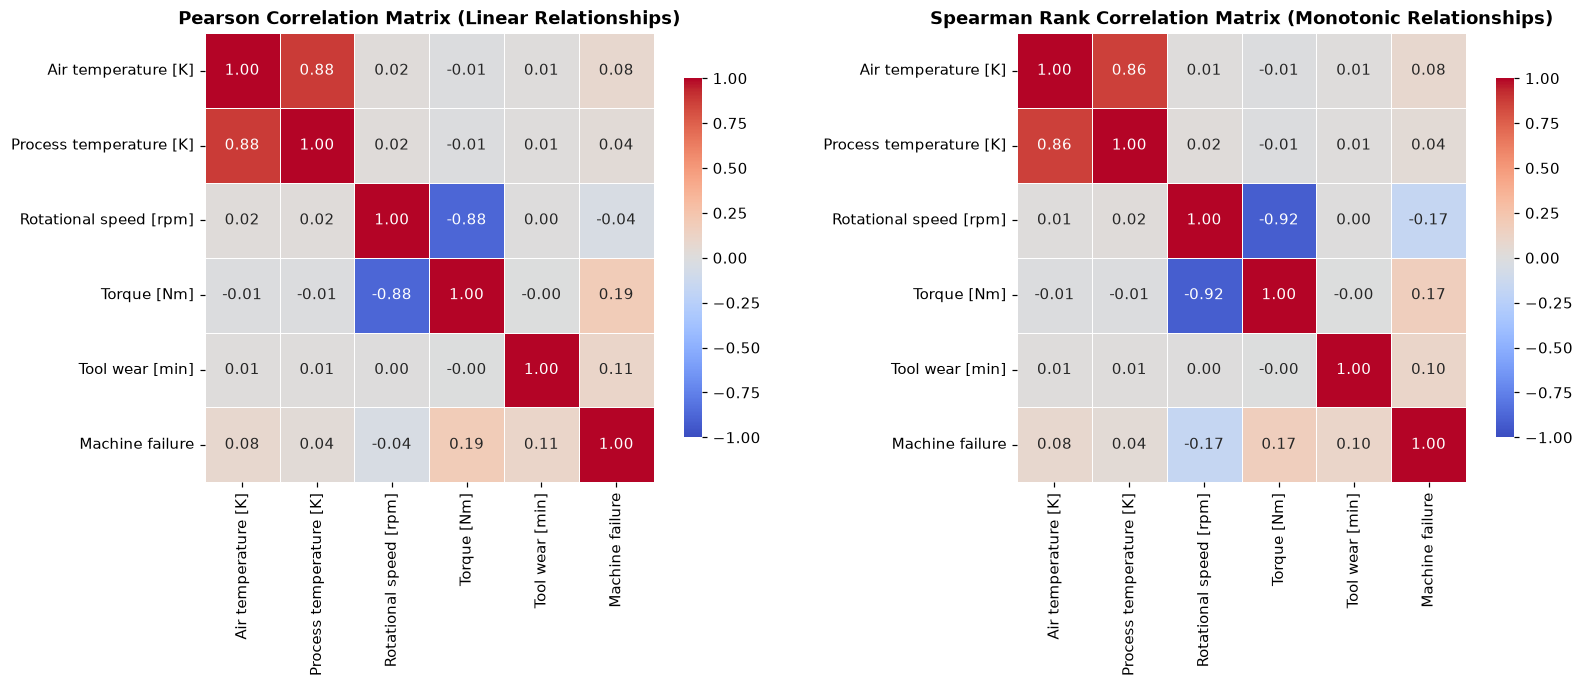

,Pearson Correlation (r),Spearman Correlation (rho)
Torque [Nm],0.191321,0.169413
Tool wear [min],0.105448,0.101630
Air temperature [K],0.082556,0.083223
Process temperature [K],0.035946,0.039946
Rotational speed [rpm],-0.044188,-0.167188


In [21]:
corr_columns = num_cols + ['Machine failure']

pearson_matrix = df[corr_columns].corr(method='pearson')
spearman_matrix = df[corr_columns].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(pearson_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[0].set_title('Pearson Correlation Matrix (Linear Relationships)', fontweight='bold')

sns.heatmap(spearman_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=axes[1], cbar_kws={'shrink': 0.8}, linewidths=0.5)
axes[1].set_title('Spearman Rank Correlation Matrix (Monotonic Relationships)', fontweight='bold')

plt.tight_layout()
plt.show()

corr_with_target = pd.DataFrame({
    'Pearson Correlation (r)': pearson_matrix['Machine failure'].drop('Machine failure'),
    'Spearman Correlation (rho)': spearman_matrix['Machine failure'].drop('Machine failure')
}).sort_values(by='Pearson Correlation (r)', ascending=False)

display(corr_with_target)


**Observations on Multicollinearity & Correlation**:
1. **Severe Thermal Multicollinearity**:
   - `Air temperature [K]` and `Process temperature [K]` have a Pearson correlation of **$r = +0.88$**.
   - Because process temperature naturally tracks ambient temperature, maintaining both in linear models will induce variance inflation and unstable coefficients.
2. **Strong Physical Coupling (Power Conservation)**:
   - `Rotational speed [rpm]` and `Torque [Nm]` exhibit a strong negative non-linear relationship: **Pearson $r = -0.88$** and **Spearman $\rho = -0.92$**.
   - Mechanical power $P = \tau \cdot \omega$ dictates that motor torque and speed trade off inversely.
3. **Target Correlation**:
   - `Torque [Nm]` has the highest correlation with failure ($r = +0.19, \rho = +0.17$), followed by `Tool wear [min]` ($r = +0.11, \rho = +0.10$).
   - `Rotational speed [rpm]` has a weak linear correlation ($r = -0.04$) but a notable rank correlation ($ho = -0.17$), reflecting its non-linear relationship with failure.


### 15. Summary of Findings & Initial Hypotheses for Later Phases

#### Synthesized EDA Findings
1. **Data Completeness & Cleanliness**:
   - The raw dataset consists of exactly **10,000 rows and 14 columns** with zero nulls, zero duplicates, and zero corrupted values.
   - `UDI` is a sequential row counter, and `Product ID` is strictly composed of the `Type` letter (`L`, `M`, or `H`) plus a unique 5-digit number. Both are non-predictive identifiers.
2. **Severe Class Imbalance**:
   - Target `Machine failure`: 9,661 negatives (96.61%) vs. 339 positives (3.39%), yielding a **28.5 : 1** imbalance ratio.
   - Model selection must rely on PR-AUC, ROC-AUC, calibrated Brier score, and cost-weighted loss rather than overall accuracy.
3. **Confirmed Target Leakage Boundaries**:
   - `TWF`, `HDF`, `PWF`, `OSF`, and `RNF` are post-hoc failure mode categorizations. Active indicators guarantee machine breakdown (except for the 18 synthetic noise instances in `RNF`).
   - All 5 columns must be quarantined and completely excluded from model inputs.
4. **Physical Interactions Govern Failure**:
   - Failures cluster along physical non-linear boundaries: tool overstrain ($Tool wear \times Torque$), mechanical power extremes ($Speed \times Torque$), and heat dissipation boundaries ($Process temp - Air temp$).
   - Product variant `Type` exhibits a statistically significant failure gradient ($p = 0.013$): variant `L` (3.92%) fails at 1.88x the rate of variant `H` (2.09%).

---

#### Initial Hypotheses for Modeling & Drift Monitoring

* **Hypothesis 1 (Non-linear Ensemble Dominance)**:
  Because industrial failure regimes depend on multiplicative physical boundaries (power and overstrain), tree-based ensemble models (Random Forest, XGBoost, LightGBM) will significantly outperform unregularized linear models unless explicit interaction features are provided.
* **Hypothesis 2 (Temperature Difference Feature Utility)**:
  Engineering a domain-grounded temperature differential feature ($\Delta T = \text{Process temp} - \text{Air temp}$) will eliminate collinearity between the temperature features and provide a direct physical proxy for the Heat Dissipation Failure (`HDF`) decision boundary (where $\Delta T < 8.6$ K).
* **Hypothesis 3 (Mechanical Power Envelope as a Drift & Anomaly Signal)**:
  Computing mechanical power ($P = \text{Speed} \times \text{Torque} \times \frac{2\pi}{60}$) will yield a highly informative univariate feature for both failure prediction and automated drift detection, as normal machines operate strictly between 3,500 W and 9,000 W.
* **Hypothesis 4 (Probability Miscalibration under Severe Imbalance)**:
  Due to the 28.5 : 1 class imbalance, raw probability outputs from tree ensembles will exhibit systematic miscalibration, requiring post-hoc probability calibration (Platt scaling or Isotonic regression) before applying conformal prediction intervals or cost-sensitive operating thresholds.
* **Hypothesis 5 (Differential Drift Sensitivity)**:
  Covariate drift introduced into `Torque` or `Rotational speed` will cause significantly more rapid degradation in model precision and recall than drift in ambient `Air temperature`, due to the steep physical failure boundaries along the torque-power axis.
